# Capacité vs débit des usines : analyse de portefeuille bidimensionnelle avec PROC SGPLOT

## Résumé exécutif

Un portefeuille de production en fabrication discrète comporte deux chiffres qui comptent à la fois pour chaque ligne de produit : **la quantité de capacité machine qu'elle consomme** et **la quantité de bonne production qu'elle livre réellement**. Un graphique à barres unidimensionnel ne peut montrer qu'un seul de ces deux chiffres. Ce notebook visualise les deux ensemble avec `PROC SGPLOT`, en utilisant un **graphique à bulles** comme vue centrale — chaque ligne est positionnée par capacité (x) et débit (y), la taille de la bulle codant son taux de productivité (unités par heure-machine). Les lignes situées en bas à droite (beaucoup de capacité, peu de production) sont des puits de capacité ; les lignes situées en haut à gauche avec une grande bulle sont à haut rendement. Une vue en barres groupées décompose ensuite le débit par usine, et un classement de productivité confirme l'écart.

D'après la sortie réellement exécutée (huit lignes de produit réparties sur trois usines, 100 séries au niveau poste agrégées en 24 cellules ligne-par-usine), l'analyse montre que **Moulage** est le puits de capacité le plus net du portefeuille (14.3 bonnes unités par heure-machine — elle consomme 10.1 % de la capacité totale mais ne livre que 3.2 % des bonnes unités) tandis qu'**Emballage** est la ligne à haut rendement la plus remarquable (119.2 unités par heure — 9.1 % de la capacité restitue 23.8 % de la production). Entre usines, **Stuttgart** tourne le plus fort à 49.9 unités/h et **Monterrey** le plus bas à 41.6.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Séries de production synthétiques au niveau poste sur 8 lignes de produit, 3 usines et 3 postes — heures machine planifiées, heures de production, arrêts, unités brutes/rebutées/bonnes (plafonné à 100 observations en mode sans licence) | 100 |
| WORK.LINE_CAPACITY | Résumé agrégé par ligne de produit et par usine : total des heures de capacité (x), bonnes unités produites (y), et % de rendement des unités acceptées | 24 |

*Toutes les données sont synthétiques et générées dans le notebook avec une graine fixe — aucun fichier externe, aucun réseau.*

# Analyse capacité vs débit des usines

**Domaine :** Fabrication discrète — opérations / génie industriel

**Procédure :** `PROC SGPLOT` (ODS Statistical Graphics)

Un graphique à barres classique montre une seule réponse par catégorie. Pour comparer un portefeuille de production sur **deux** dimensions numériques à la fois — *la capacité que consomme chaque ligne de produit* face à *la production qu'elle livre réellement* — il nous faut un graphique qui place les deux sur le même canevas. L'instruction `BUBBLE` de `PROC SGPLOT` fait exactement cela : elle positionne chaque ligne par capacité (x) et bonnes unités (y) et laisse une troisième mesure, le taux de productivité, piloter la taille de la bulle. Une ligne située loin à droite mais bas est un puits de capacité ; une ligne située haut et à gauche avec une grosse bulle est une ligne à haut rendement qu'il vaut la peine de protéger. Ce notebook construit un jeu de données de production synthétique réaliste et pilote SGPLOT à travers un graphique à bulles, un graphique à barres groupées par usine, une analyse détaillée d'une seule usine, et une comparaison groupée côte à côte des usines.

> **Une remarque sur PROC GAREABAR.** La façon classique de SAS/GRAPH d'encoder deux dimensions par *barre* est `PROC GAREABAR` (un graphique barres-aires ActiveX uniquement où la largeur de la barre encode une variable et la hauteur une autre). GAREABAR n'est **pas encore implémenté dans cette version de Jenner** — cette lacune est suivie par le test banque `tests/400996_nb_gareabar_unimplemented`. Ce notebook atteint le même objectif analytique avec `PROC SGPLOT`, entièrement pris en charge, dont les vues à bulles et à barres groupées transmettent la même histoire de capacité vs débit.

## 1. Générer des données de production synthétiques

Nous simulons six semaines de séries de production au niveau poste pour un réseau de fabrication discrète à trois usines. Chaque ligne de produit a un temps de cycle de base et un taux de rebut ; le débit est déterminé par les heures machine planifiées, l'efficacité propre à la ligne, et des arrêts aléatoires. `call streaminit` fixe la graine afin que le notebook soit entièrement reproductible — aucun fichier externe, aucun réseau.

In [1]:
/* --------------------------------------------------------
   Séries de production synthétiques au niveau poste
   8 lignes de produit x 3 usines x 3 postes x ~10 jours
   var largeur = heures machine planifiées (capacité)
   réponse     = bonnes unités produites (débit)
   -------------------------------------------------------- */
DONNÉES work.production_runs;
    APPELER streaminit(20260531);
    LONGUEUR product_line $18 plant $12 shift $8;

    TABLEAU line_names[8] $18 _temporary_
        ('Emboutissage'  'Soudage'   'Usinage' 'Moulage'
         'Injection' 'Assemblage'  'Finition' 'Emballage');
    /* unités nominales produites par heure-machine, par ligne */
    TABLEAU line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* fraction de rebut de base par ligne */
    TABLEAU line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    TABLEAU plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* multiplicateur d'efficacité par usine */
    TABLEAU plant_eff[3] _temporary_ (1.00 0.92 1.08);
    TABLEAU shift_names[3] $8 _temporary_ ('Jour' 'Soir' 'Nuit');
    TABLEAU shift_eff[3] _temporary_ (1.00 0.95 0.88);

    FAIRE day = 1 JUSQU_À 10;
        FAIRE li = 1 JUSQU_À 8;
            FAIRE pi = 1 JUSQU_À 3;
                FAIRE si = 1 JUSQU_À 3;
                    product_line = line_names[li];
                    plant        = plant_names[pi];
                    shift        = shift_names[si];

                    /* heures machine planifiées pour le poste */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* les arrêts non planifiés grignotent la capacité */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* taux de débit effectif avec bruit */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    SORTIE;
                FIN;
            FIN;
        FIN;
    FIN;
    GARDER run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    format run_date date9.;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.production_runs(obs=8) noobs ÉTIQUETTE;
    ÉTIQUETTE run_date="Date" product_line="Ligne de produit" plant="Usine" shift="Poste"
          sched_hours="Heures planifiées" run_hours="Heures de production"
          downtime_hours="Heures d'arrêt" gross_units="Unités brutes"
          scrap_units="Unités rebutées" good_units="Bonnes unités";
    TITRE "Échantillon de données de production synthétiques par poste";
EXÉCUTER;
TITRE;

                              Échantillon de données de production synthétiques par poste                               

     Date  Ligne de produit      Usine  Poste   Heures planifiées  Heures de production   Heures d'arrêt   Unités brutes    Unités rebutées   Bonnes unités
05JAN2026  Emboutissage      Detroit    Jour                  7.8                   6.7              1.1             306                 14             292
05JAN2026  Emboutissage      Detroit    Soir                  6.8                   6.5              0.3             259                 12             247
05JAN2026  Emboutissage      Detroit    Nuit                    8                   7.6              0.4             269                 11             258
05JAN2026  Emboutissage      Monterrey  Jour                  7.9                   6.8              1.1             283                 12             271
05JAN2026  Emboutissage      Monterrey  Soir                  7.5                   6.9           


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.17 seconds
  cpu   0.17 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Agréger au niveau ligne et usine

Les graphiques comparent un point par catégorie, donc nous remontons le détail au niveau poste vers un résumé par ligne de produit et par usine. `total_capacity` (somme des heures machine planifiées) devient la dimension **x**, `good_units` (somme de la production acceptée) la dimension **y**, et `units_per_hr` (bonnes unités ÷ heures de capacité) le taux de productivité qui dimensionnera les bulles. Nous conservons `plant` afin qu'elle puisse servir de variable de groupement plus tard. Nous construisons aussi un résumé au niveau ligne (toutes usines confondues) pour le graphique à bulles du portefeuille.

In [2]:
/* --------------------------------------------------------
   Remonter au niveau product_line x plant
   total_capacity -> x (heures de capacité)
   good_units     -> y (débit)
   units_per_hr   -> taille de bulle (productivité)
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.production_runs SANS_IMPRESSION NWAY;
    CLASSE product_line plant;
    VAR sched_hours good_units scrap_units;
    SORTIE out=work.line_capacity(SUPPRIMER=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
EXÉCUTER;

DONNÉES work.line_capacity;
    DÉFINIR work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    format units_per_hr 6.1 yield_pct 5.1;
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=work.line_capacity;
    PAR product_line plant;
EXÉCUTER;

/* Remontée au niveau ligne (toutes les trois usines confondues) pour la vue portefeuille */
PROCÉDURE MOYENNES DONNÉES=work.line_capacity SANS_IMPRESSION NWAY;
    CLASSE product_line;
    VAR total_capacity good_units;
    SORTIE out=work.line_total(SUPPRIMER=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
EXÉCUTER;

DONNÉES work.line_total;
    DÉFINIR work.line_total;
    units_per_hr = good_units / total_capacity;
    format units_per_hr 6.1;
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=work.line_total;
    PAR units_per_hr;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.line_total noobs ÉTIQUETTE;
    VAR product_line total_capacity good_units units_per_hr;
    ÉTIQUETTE product_line="Ligne de produit" total_capacity="Capacité totale (heures)"
          good_units="Bonnes unités" units_per_hr="Unités par heure";
    TITRE "Lignes du portefeuille classées par productivité (bonnes unités par heure-machine)";
EXÉCUTER;
TITRE;

                   Lignes du portefeuille classées par productivité (bonnes unités par heure-machine)                   

Ligne de produit   Capacité totale (heures)   Bonnes unités   Unités par heure
Moulage                                73.4            1050               14.3
Soudage                               130.8            3038               23.2
Usinage                               128.9            3762               29.2
Emboutissage                          130.7            4713               36.1
Injection                              66.2            3430               51.8
Assemblage                             67.3            4289               63.7
Finition                               64.6            4927               76.3
Emballage                              65.9            7855              119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Ouvrir la destination ODS Graphics

`PROC SGPLOT` s'affiche via ODS Statistical Graphics. Nous ouvrons une destination `ODS HTML` afin que chaque graphique soit émis en image, et activons `ODS GRAPHICS ON`. Aucun pilote de périphérique spécial n'est requis — SGPLOT est indépendant du périphérique, contrairement aux procédures SAS/GRAPH ActiveX uniquement.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Graphique à bulles du portefeuille — capacité vs débit

La vue centrale : `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Chaque ligne de produit est une bulle, positionnée par le total des heures de capacité (x) et le total des bonnes unités (y), l'aire de la bulle étant proportionnelle à son taux de productivité. `DATALABEL=` affiche le nom de la ligne à côté de chaque bulle. C'est la comparaison bidimensionnelle que veut un responsable d'usine — les puits de capacité tombent en **bas à droite** (beaucoup d'heures, peu de production, petite bulle) ; les lignes à haut rendement montent en **haut à gauche** (peu d'heures, beaucoup de production, grosse bulle).

                                     Portefeuille de production - Capacité vs débit                                     
                 x = heures machine planifiées ; y = bonnes unités ; taille de bulle = unités par heure                 


En bas à droite = puits de capacité ; en haut à gauche avec une grande bulle = ligne à haut rendement.



NOTE: Option TITLE changed to Portefeuille de production - Capacité vs débit.
NOTE: Option TITLE2 changed to x = heures machine planifiées ; y = bonnes unités ; taille de bulle = unités par heure.
NOTE: Option FOOTNOTE changed to En bas à droite = puits de capacité ; en haut à gauche avec une grande bulle = ligne à haut rendement..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


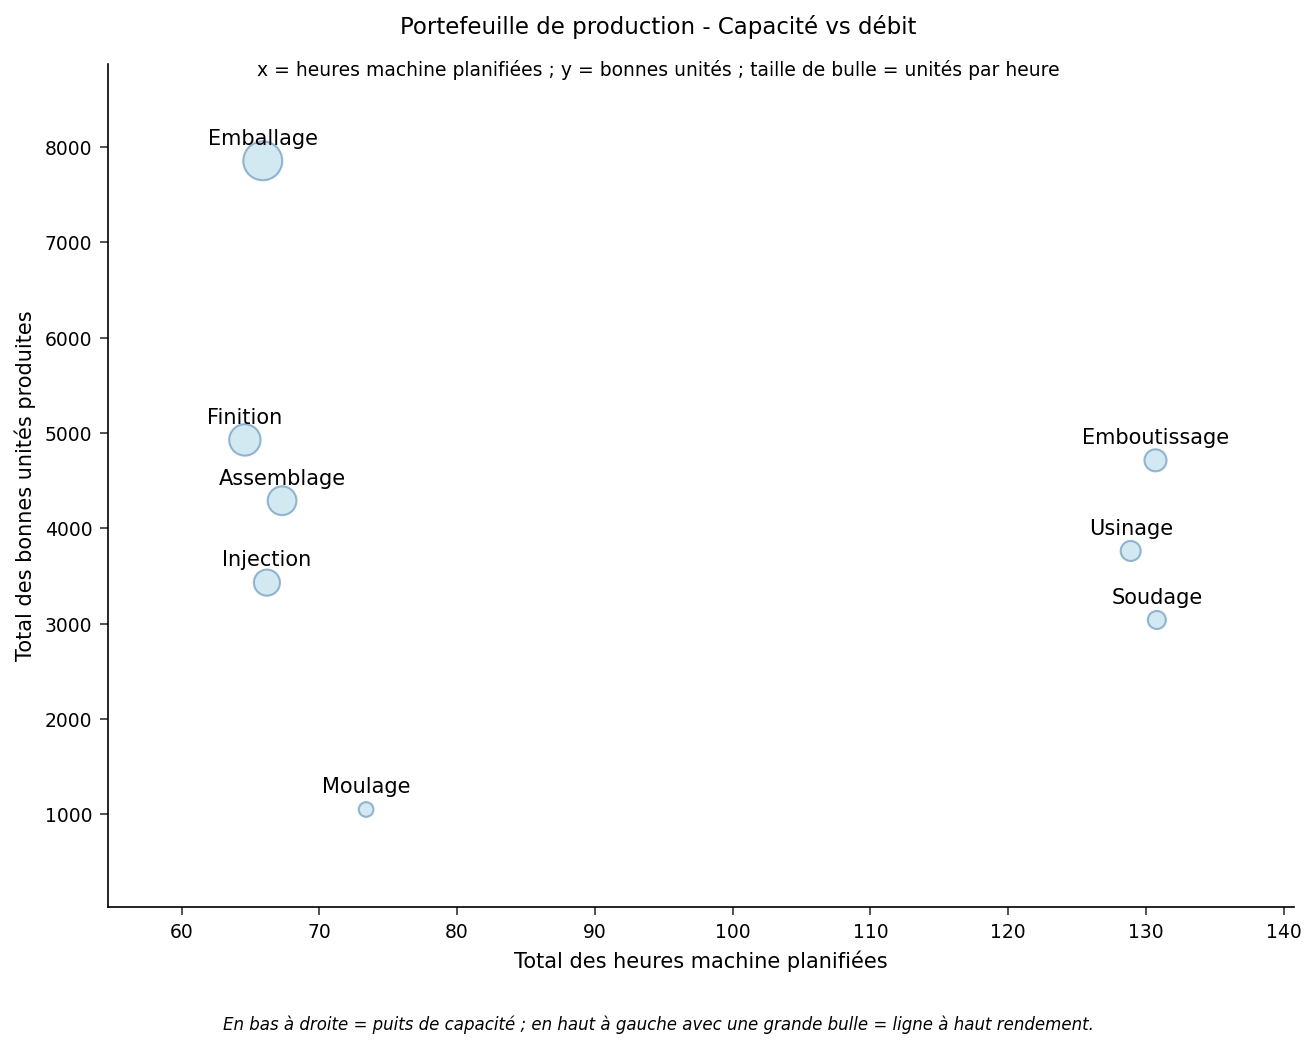

In [4]:
TITRE "Portefeuille de production - Capacité vs débit";
title2 "x = heures machine planifiées ; y = bonnes unités ; taille de bulle = unités par heure";
footnote JUSTIFY=GAUCHE
    "En bas à droite = puits de capacité ; en haut à gauche avec une grande bulle = ligne à haut rendement.";

PROCÉDURE SGPLOT DONNÉES=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ÉTIQUETTE="Total des heures machine planifiées";
    YAXIS ÉTIQUETTE="Total des bonnes unités produites";
EXÉCUTER;

TITRE; title2; footnote;

## 5. Débit par ligne, décomposé par usine

Pour voir comment la production de chaque ligne se répartit entre les trois usines, un graphique `VBAR product_line / response=good_units group=plant` empile les contributions des usines dans chaque barre. C'est la vue de segmentation : elle montre à la fois la hauteur totale (bonnes unités par ligne) et le mélange d'usines à l'intérieur de chaque barre, afin de repérer les lignes où une usine domine la production.

                                 Bonnes unités par ligne de produit, empilées par usine                                 
                    Hauteur de barre = total des bonnes unités ; segments = contribution de l'usine                     




NOTE: Option TITLE changed to Bonnes unités par ligne de produit, empilées par usine.
NOTE: Option TITLE2 changed to Hauteur de barre = total des bonnes unités ; segments = contribution de l'usine.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


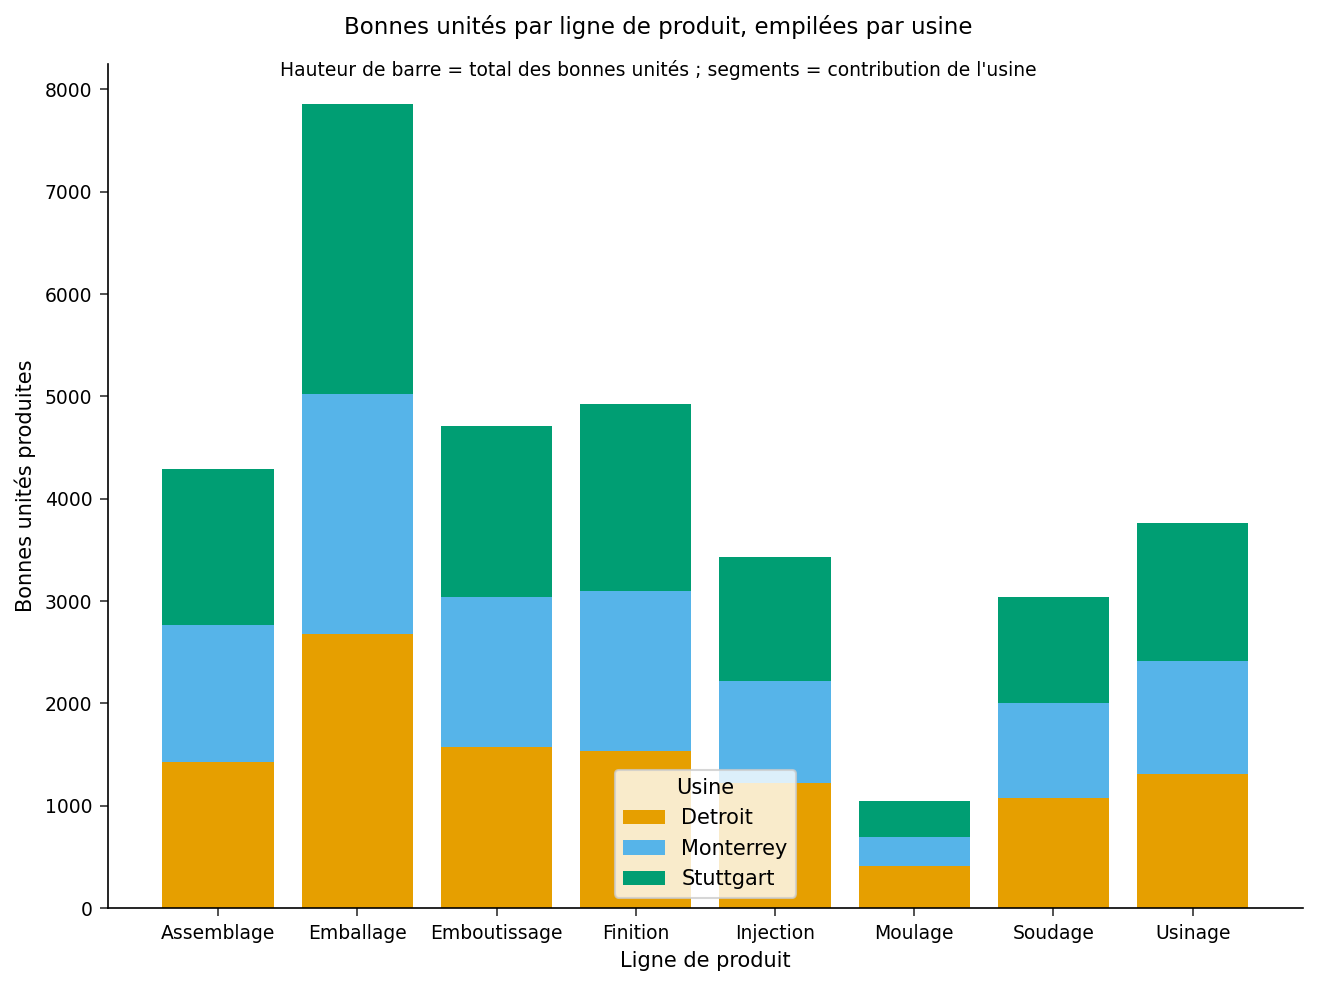

In [5]:
TITRE "Bonnes unités par ligne de produit, empilées par usine";
title2 "Hauteur de barre = total des bonnes unités ; segments = contribution de l'usine";

PROCÉDURE SGPLOT DONNÉES=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUPE=plant
        GROUPDISPLAY=stack;
    XAXIS ÉTIQUETTE="Ligne de produit" fitpolicy=ROTATE;
    YAXIS ÉTIQUETTE="Bonnes unités produites";
    keylegend / TITRE="Usine" position=bottom;
EXÉCUTER;

TITRE; title2;

## 6. Analyse détaillée d'une seule usine par productivité (WHERE)

Les barres horizontales (`HBAR`) conviennent aux libellés de ligne de produit longs. Une clause `WHERE` restreint à l'usine de Stuttgart, et les barres sont tracées pour `units_per_hr` afin que le graphique classe les lignes de Stuttgart par productivité. Comme l'entrée est triée par ordre croissant de taux, la ligne la moins productive se trouve en bas et la plus productive en haut.

                                 Usine de Stuttgart - Lignes classées par productivité                                  


Longueur de barre = bonnes unités par heure-machine (analyse détaillée d'une seule usine).



NOTE: Option TITLE changed to Usine de Stuttgart - Lignes classées par productivité.
NOTE: Option FOOTNOTE changed to Longueur de barre = bonnes unités par heure-machine (analyse détaillée d'une seule usine)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


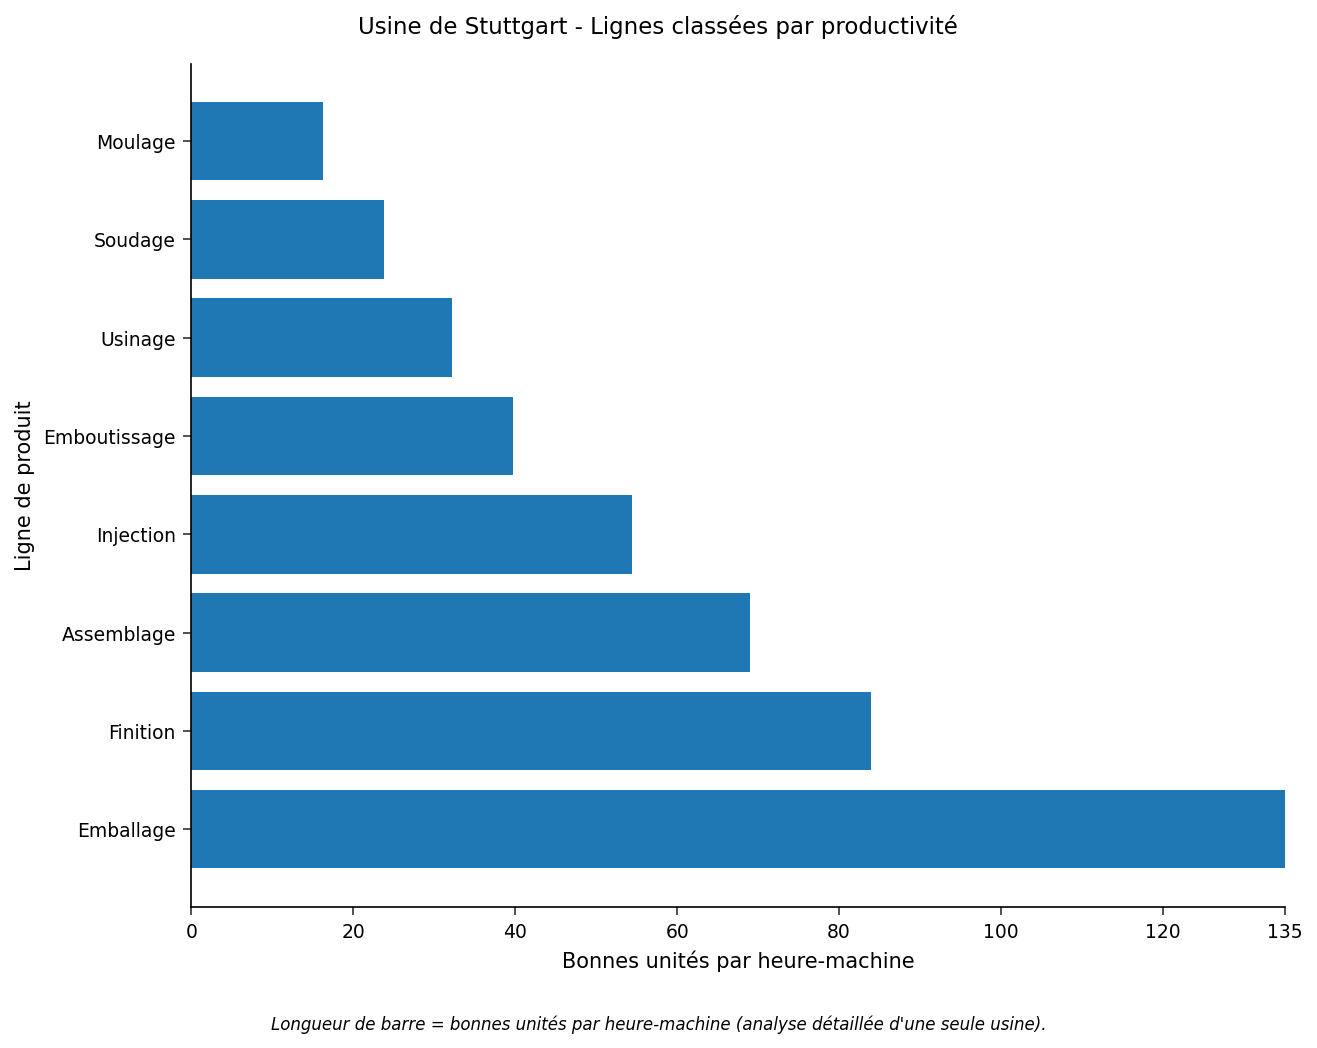

In [6]:
TITRE "Usine de Stuttgart - Lignes classées par productivité";
footnote JUSTIFY=GAUCHE "Longueur de barre = bonnes unités par heure-machine (analyse détaillée d'une seule usine).";

PROCÉDURE SGPLOT DONNÉES=work.line_capacity;
    OÙ plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ÉTIQUETTE="Bonnes unités par heure-machine";
    YAXIS ÉTIQUETTE="Ligne de produit";
EXÉCUTER;

TITRE; footnote;

## 7. Comparaison côte à côte des usines (barres groupées)

Pour comparer les trois usines ligne par ligne, un graphique à barres groupées (`GROUPDISPLAY=CLUSTER`) trace Detroit, Monterrey et Stuttgart comme des barres adjacentes au sein de chaque ligne de produit. C'est la vue comparative directe entre usines : pour n'importe quelle ligne, on peut lire quelle usine a produit le plus de bonnes unités, rendant directement visibles les écarts d'efficacité entre usines (Stuttgart la plus haute, Monterrey la plus basse).

                                     Bonnes unités par ligne et usine - côte à côte                                     
                           Barres groupées : une barre par usine pour chaque ligne de produit                           




NOTE: Option TITLE changed to Bonnes unités par ligne et usine - côte à côte.
NOTE: Option TITLE2 changed to Barres groupées : une barre par usine pour chaque ligne de produit.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


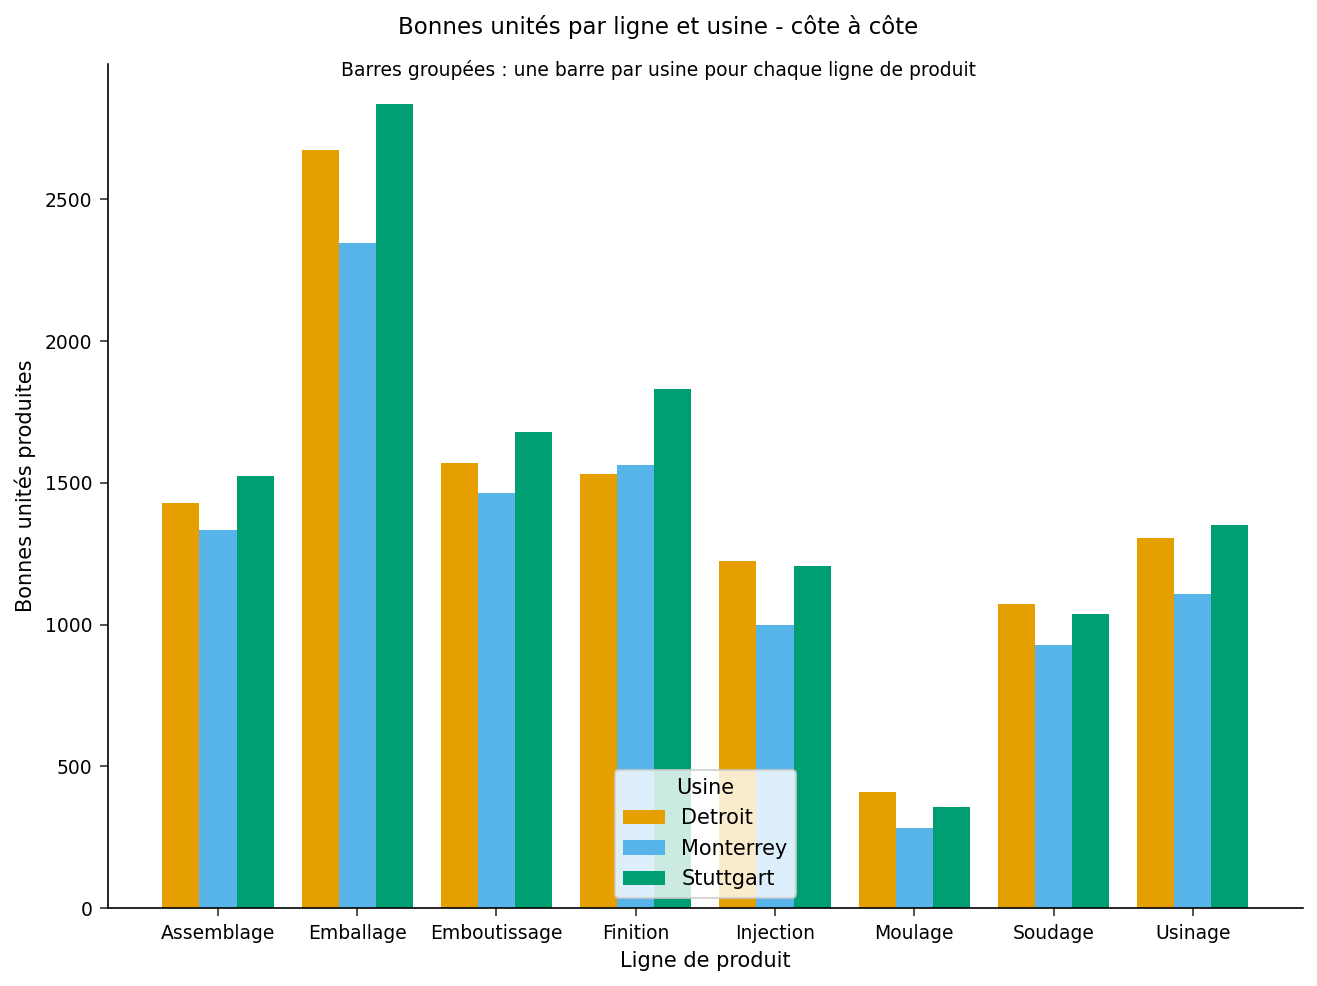

In [7]:
TITRE "Bonnes unités par ligne et usine - côte à côte";
title2 "Barres groupées : une barre par usine pour chaque ligne de produit";

PROCÉDURE SGPLOT DONNÉES=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUPE=plant
        GROUPDISPLAY=GRAPPE;
    XAXIS ÉTIQUETTE="Ligne de produit" fitpolicy=ROTATE;
    YAXIS ÉTIQUETTE="Bonnes unités produites";
    keylegend / TITRE="Usine" position=bottom;
EXÉCUTER;

TITRE; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Interprétation

Tracer la capacité et le débit sur les mêmes axes révèle une relation qu'un graphique à barres unidimensionnel dissimulerait. **Moulage** est le puits de capacité le plus net du portefeuille : dans le classement de productivité elle se trouve en bas à **14.3 bonnes unités par heure-machine**, et dans le graphique à bulles elle tombe en bas à gauche sous forme de petite bulle — elle consomme **10.1 %** du total des heures planifiées mais ne restitue que **3.2 %** des bonnes unités (elle porte aussi le rendement le plus bas, ~91 %, du fait de sa forte fraction de rebut). C'est la première candidate pour un kaizen de réduction du temps de cycle et du rebut. À l'opposé, **Emballage** est la ligne à haut rendement la plus remarquable à **119.2 unités par heure-machine** — une grosse bulle haute sur l'axe du débit qui transforme **9.1 %** de la capacité en **23.8 %** de toutes les bonnes unités ; protéger sa disponibilité produit une production disproportionnée. **Finition** (76.3 unités/h) et **Assemblage** (63.7) suivent le même schéma de haut rendement.

Le schéma est systématique : les quatre lignes amont lentes et gourmandes en capacité — Moulage, Soudage (23.2 unités/h), Usinage (29.2) et Emboutissage (36.1) — consomment ensemble environ **64 %** des heures planifiées mais ne livrent qu'environ **38 %** des bonnes unités, tandis que les quatre lignes aval rapides surproduisent par rapport aux heures qu'elles consomment. La vue empilée par usine et les barres groupées côte à côte montrent la dimension usine derrière cela : **Stuttgart** tourne le plus fort à **49.9 bonnes unités par heure-machine**, **Detroit** est au milieu à **44.9**, et **Monterrey** est à la traîne à **41.6** — cohérent avec les arrêts plus élevés modélisés pour Monterrey. Sur le plan opérationnel, cela suggère de rééquilibrer les heures planifiées vers les lignes aval à haut rendement et de comparer les arrêts de Monterrey aux pratiques de Stuttgart.

*Données synthétiques uniquement — les chiffres illustrent la visualisation bidimensionnelle capacité-vs-débit avec PROC SGPLOT, non la performance réelle d'une usine.*